In [1]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
from config import DATA_PATHS

PROJECT_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

df = pd.read_csv(DATA_PATHS["stats_dir"] / "fighter_stats.csv")

df.head()

,name,wins,losses,height,weight,reach,stance,age,SLpM,sig_str_acc,SApM,str_def,td_avg,td_acc,td_def,sub_avg
0,Amanda Ribas,12.0,5.0,160.02,56.70,167.64,Orthodox,30.0,4.63,0.40,3.40,0.61,2.07,0.51,0.85,0.7
1,Rose Namajunas,13.0,6.0,165.10,56.70,165.10,Orthodox,31.0,3.69,0.41,3.51,0.63,1.38,0.47,0.59,0.5
2,Karl Williams,10.0,1.0,190.50,106.59,200.66,Orthodox,34.0,2.87,0.52,1.70,0.60,4.75,0.50,1.00,0.2
3,Justin Tafa,7.0,4.0,182.88,119.75,187.96,Southpaw,30.0,4.09,0.54,5.02,0.47,0.00,0.00,0.50,0.0
4,Edmen Shahbazyan,13.0,4.0,187.96,83.91,190.50,Orthodox,26.0,3.60,0.52,4.09,0.45,2.24,0.38,0.63,0.6


In [2]:
df.columns

Index(['name', 'wins', 'losses', 'height', 'weight', 'reach', 'stance', 'age',
       'SLpM', 'sig_str_acc', 'SApM', 'str_def', 'td_avg', 'td_acc', 'td_def',
       'sub_avg'],
      dtype='str')

In [3]:
df.describe()

,wins,losses,height,weight,reach,age,SLpM,sig_str_acc,SApM,str_def,td_avg,td_acc,td_def,sub_avg
count,2478.000000,2478.000000,2478.000000,2478.000000,1823.000000,2318.000000,2478.000000,2478.000000,2478.000000,2478.000000,2478.000000,2478.000000,2478.000000,2478.000000
mean,14.399112,6.111380,178.384262,76.876852,182.035656,37.727783,2.932623,0.406029,3.388567,0.488910,1.393543,0.322571,0.494972,0.602179
std,9.853474,4.548011,8.851777,17.976646,10.654129,7.251188,1.736693,0.151297,2.027258,0.162305,1.512821,0.256928,0.297551,1.057863
min,0.000000,0.000000,152.400000,52.160000,147.320000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,3.000000,172.720000,65.770000,175.260000,32.000000,1.810000,0.360000,2.320000,0.450000,0.120000,0.070000,0.300000,0.000000
50%,13.000000,5.000000,177.800000,77.110000,182.880000,37.000000,2.900000,0.430000,3.230000,0.520000,1.000000,0.330000,0.550000,0.300000
75%,18.000000,8.000000,185.420000,83.910000,190.500000,42.000000,3.920000,0.500000,4.290000,0.580000,2.065000,0.480000,0.710000,0.800000
max,253.000000,53.000000,210.820000,349.270000,213.360000,81.000000,23.330000,1.000000,42.000000,1.000000,13.950000,1.000000,1.000000,16.400000


In [4]:
print(df.columns)

Index(['name', 'wins', 'losses', 'height', 'weight', 'reach', 'stance', 'age',
       'SLpM', 'sig_str_acc', 'SApM', 'str_def', 'td_avg', 'td_acc', 'td_def',
       'sub_avg'],
      dtype='str')


In [5]:
# fill the na's reaches with imputed median reach
median_reach = df['reach'].median()
df['imputed_reach'] = df['reach'].fillna(median_reach)
df['reach'] = df['imputed_reach']

df['reach']


0       167.64
1       165.10
2       200.66
3       187.96
4       190.50
         ...  
2474    182.88
2475    182.88
2476    182.88
2477    182.88
2478    182.88
Name: reach, Length: 2479, dtype: float64

In [6]:
nas = 0
normal = 0

nas = df["stance"].isna().sum()
normal = df["stance"].notna().sum()
total = len(df)

print(f"Missing data -> {nas} ({nas / total * 100:.2f}% of data)")
print(f"Present data -> {normal} ({normal / total * 100:.2f}% of data)")

Missing data -> 78 (3.15% of data)
Present data -> 2401 (96.85% of data)


Since the distirubution of missing values is not major, I will fill it with "Missing" label

In [7]:
for val in df["stance"]:
    df["stance"] = df["stance"].fillna("Missing")

df['stance']

0       Orthodox
1       Orthodox
2       Orthodox
3       Southpaw
4       Orthodox
          ...   
2474     Missing
2475     Missing
2476     Missing
2477     Missing
2478     Missing
Name: stance, Length: 2479, dtype: str

Now to the ages

In [8]:
df.isna().sum()

name               1
wins               1
losses             1
height             1
weight             1
reach              0
stance             0
age              161
SLpM               1
sig_str_acc        1
SApM               1
str_def            1
td_avg             1
td_acc             1
td_def             1
sub_avg            1
imputed_reach      0
dtype: int64

In [9]:
# Join age column ON name column
df_large = pd.read_csv(DATA_PATHS["large_set"] / "large_dataset.csv")
df_stats = df
df_large.head()

,event_name,r_fighter,b_fighter,winner,weight_class,is_title_bout,gender,method,finish_round,total_rounds,...,weight_diff,reach_diff,SLpM_total_diff,SApM_total_diff,sig_str_acc_total_diff,td_acc_total_diff,str_def_total_diff,td_def_total_diff,sub_avg_diff,td_avg_diff
0,UFC Fight Night: Ribas vs. Namajunas,Amanda Ribas,Rose Namajunas,Blue,Women's Flyweight,0,Women,Decision - Unanimous,5,5.0,...,0.00,2.54,0.94,-0.11,-0.01,0.04,-0.02,0.26,0.2,0.69
1,UFC Fight Night: Ribas vs. Namajunas,Karl Williams,Justin Tafa,Red,Heavyweight,0,Men,Decision - Unanimous,3,3.0,...,-13.16,12.70,-1.22,-3.32,-0.02,0.50,0.13,0.50,0.2,4.75
2,UFC Fight Night: Ribas vs. Namajunas,Edmen Shahbazyan,AJ Dobson,Red,Middleweight,0,Men,KO/TKO,1,3.0,...,0.00,-2.54,-0.69,-1.22,0.06,-0.37,-0.01,-0.02,0.3,0.57
3,UFC Fight Night: Ribas vs. Namajunas,Payton Talbott,Cameron Saaiman,Red,Bantamweight,0,Men,KO/TKO,2,3.0,...,0.00,7.62,2.73,-0.60,0.08,-0.28,0.00,0.43,-0.2,-0.91
4,UFC Fight Night: Ribas vs. Namajunas,Billy Quarantillo,Youssef Zalal,Blue,Featherweight,0,Men,Submission,2,3.0,...,0.00,-5.08,4.48,3.84,0.07,-0.11,-0.22,0.01,-0.2,-1.04


In [10]:
# now join genders with fighter stats
# use a separate library called gender-guesser
from gender_guesser.detector import Detector
d = Detector()

names = df['name']
genders = []

for name in names:
    if pd.isna(name):
        pred = 'unknown'
    else:
        first_name = str(name).split()[0].capitalize()
        pred = d.get_gender(first_name)
    genders.append(pred)

df['gender'] = pd.Series(genders, index=df.index)
df[['name', 'gender']].head()

,name,gender
0,Amanda Ribas,female
1,Rose Namajunas,female
2,Karl Williams,male
3,Justin Tafa,male
4,Edmen Shahbazyan,unknown


<Axes: xlabel='gender', ylabel='count'>

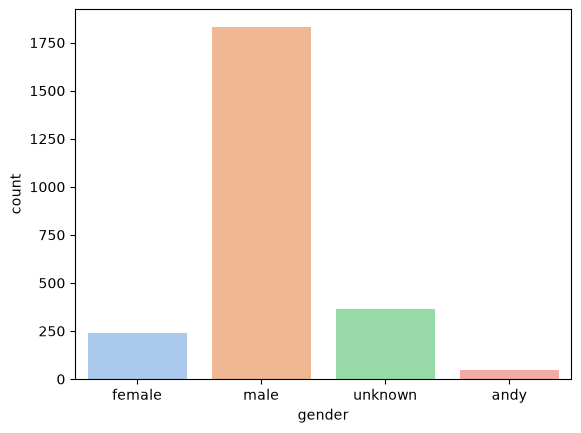

In [14]:
# Normalize gender-guesser categories while preserving unknown values
gender_map = {
    "mostly_male": "male",
    "mostly_female": "female",
}

df["gender"] = df["gender"].replace(gender_map)

sns.countplot(
    data=df,
    x="gender",
    hue="gender",
    palette="pastel",
    legend=False,
)

364
14.68


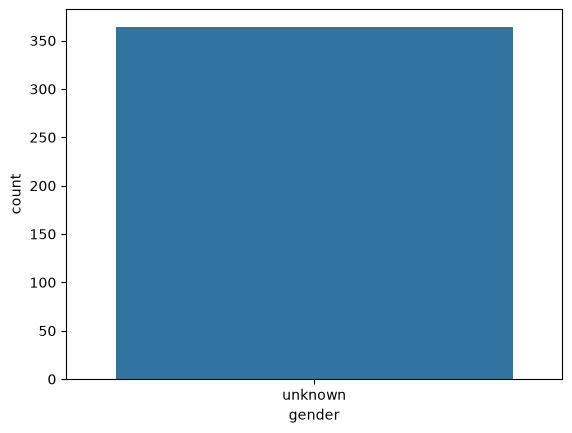

In [ ]:
unknown_gender = df_stats[df_stats["gender"] == "unknown"]

sns.countplot(
    data=unknown_gender,
    x="gender",
)
print(len(unknown_gender))
print(round(len(unknown_gender) / df['gender'].count() * 100, 2))

In [22]:
# Replace unknown genders with a balanced 50/50 split
unknown_mask = df["gender"].eq("unknown")
unknown_indices = df.index[unknown_mask]

half = len(unknown_indices) // 2
female_indices = unknown_indices[:half]
male_indices = unknown_indices[half:]

df.loc[female_indices, "gender"] = "female"
df.loc[male_indices, "gender"] = "male"

df["gender"].value_counts()


gender
male      2013
female     419
andy        47
Name: count, dtype: int64

In [23]:
# Fill missing ages using the median age for each gender
gender_medians = df.groupby("gender")["age"].transform("median")

df["age"] = df["age"].fillna(gender_medians)
df["age"] = df["age"].fillna(df["age"].median())

df["age"].isna().sum()

np.int64(0)

In [ ]:
df_stats.isna().sum()

name             1
wins             1
losses           1
height           1
weight           1
reach            0
stance           0
age              0
SLpM             1
sig_str_acc      1
SApM             1
str_def          1
td_avg           1
td_acc           1
td_def           1
sub_avg          1
imputed_reach    0
gender           0
dtype: int64

In [29]:
# Impute numeric columns with their column means
numeric_cols = df_stats.select_dtypes(include="number").columns
df_stats[numeric_cols] = df_stats[numeric_cols].fillna(
    df_stats[numeric_cols].mean()
)

# Fill missing categorical/text values with a label
categorical_cols = df_stats.select_dtypes(exclude="number").columns
df_stats[categorical_cols] = df_stats[categorical_cols].fillna("Missing")

df_stats.isna().sum()

name             0
wins             0
losses           0
height           0
weight           0
reach            0
stance           0
age              0
SLpM             0
sig_str_acc      0
SApM             0
str_def          0
td_avg           0
td_acc           0
td_def           0
sub_avg          0
imputed_reach    0
gender           0
dtype: int64

Done with cleaning (was fun lowkey)

In [32]:
output_dir = PROJECT_ROOT.parent.parent / "data"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "stats_clean.csv"
df_stats.to_csv(output_path, index=False)

print(f"Saved cleaned data to: {output_path}")

Saved cleaned data to: /Users/dimon776/Desktop/Projects/UFC-Prediction-Model/ufc_pred_model/data/stats_clean.csv
